# M4/T2 Homework: Обработка текстов PubMed Supplements

Датасет из прошлого домашнего задания:
- Выбран `PubMed`, потому что домен медицинский и с высокой ценой ошибки: нужны проверяемые источники и PMID.
- Формат `title + abstract + PMID + url` хорошо подходит для RAG: есть и короткие маркеры (title), и содержательные фрагменты (abstract).
- Отдельно сохраняются данные в `./data` для воспроизводимости эксперимента и повторного запуска без повторного запроса к API.

In [1]:
import os
import gc
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch

# Подавление предупреждений токенизаторов и трансформеров
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
import transformers
transformers.logging.set_verbosity_error()
logging.getLogger("transformers.tokenization_utils_base").setLevel(logging.ERROR)

from chonkie import TokenChunker, SentenceChunker, SemanticChunker, RecursiveChunker
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_core.documents import Document
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings("ignore")

SEED = 42
DATA_PATH = "data/pubmed_supplements_corpus.csv"
MODELS_CACHE_DIR = "./models" 

def flush_memory():
    """Принудительная очистка VRAM и RAM"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        if hasattr(torch.cuda, 'ipc_collect'):
            torch.cuda.ipc_collect()
    print("Memory flushed.")

/home/krv/repo/LLM_course/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Оценка полученных текстов

Проведем базовый анализ корпуса: распределение длин и ключевые слова.

Количество документов: 496


,char_len,word_len
count,496.000000,496.000000
mean,1863.346774,265.893145
std,549.282820,81.142316
min,402.000000,58.000000
25%,1563.000000,224.000000
50%,1786.000000,256.000000
75%,2058.000000,290.250000
max,6326.000000,994.000000


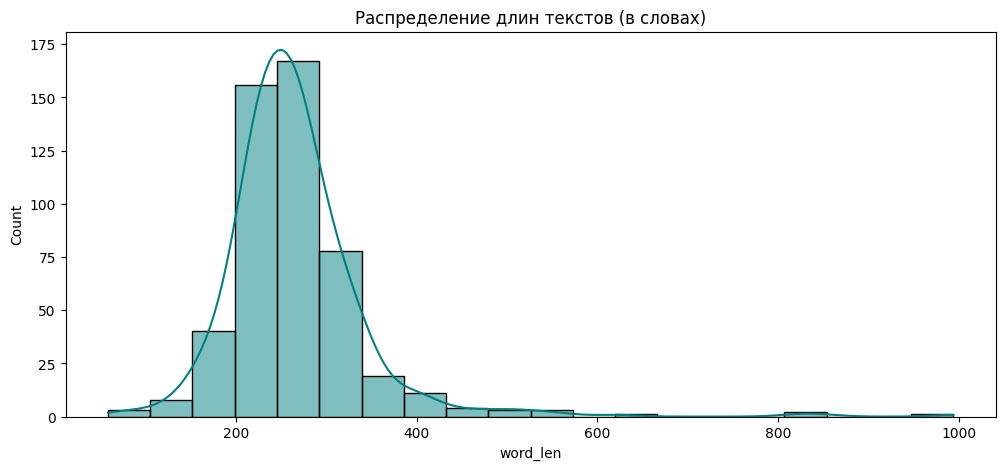

In [2]:
import re

def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\[.*?\]', '', text)
    return text.strip()

df = pd.read_csv(DATA_PATH)
df["title"] = df["title"].apply(clean_text)
df["abstract"] = df["abstract"].apply(clean_text)
df["text_full"] = df["title"] + " " + df["abstract"]

df["char_len"] = df["text_full"].str.len()
df["word_len"] = df["text_full"].str.split().str.len()

print(f"Количество документов: {len(df)}")
display(df[["char_len", "word_len"]].describe())

plt.figure(figsize=(12, 5))
sns.histplot(df["word_len"], bins=20, kde=True, color="teal")
plt.title("Распределение длин текстов (в словах)")
plt.show()

In [3]:
tfidf = TfidfVectorizer(stop_words="english", max_features=20)
tfidf_matrix = tfidf.fit_transform(df["text_full"])
print("Топ-20 ключевых слов корпуса:")
print(", ".join(tfidf.get_feature_names_out()))

Топ-20 ключевых слов корпуса:
95, analysis, ci, controlled, effect, effects, included, meta, patients, randomized, rcts, results, review, risk, significant, studies, supplementation, systematic, trials, vitamin


**Вывод по корпусу:** Тексты абстрактов достаточно короткие (в среднем ~260 слов), распределение плотное, без экстремальных выбросов. Ключевые слова подтверждают строгий медицинский домен (randomized, trial, supplementation). Такой размер текстов идеален для RAG — они информативны и легко бьются на осмысленные чанки.

## 2. Тестирование чанкеров из `chonkie` и метрики ретрива

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "sentence-transformers/all-MiniLM-L6-v2"

embeddings = HuggingFaceEmbeddings(
    model_name=model_name, 
    model_kwargs={"device": device}, 
    cache_folder=MODELS_CACHE_DIR
)

CHUNK_SIZE = 150
chunkers = {
    "Token": TokenChunker(chunk_size=CHUNK_SIZE),
    "Sentence": SentenceChunker(chunk_size=CHUNK_SIZE),
    "Semantic": SemanticChunker(embedding_model=model_name, chunk_size=CHUNK_SIZE),
    "Recursive": RecursiveChunker(chunk_size=CHUNK_SIZE)
}

# Загружаем Golden Set, сгенерированный в предыдущем ДЗ
try:
    golden_df = pd.read_csv("data/golden_supplements.csv")
    golden_set = golden_df.to_dict("records")
except FileNotFoundError:
    print("Не найден golden_supplements.csv, используем демо-набор")
    golden_set = [
        {"question": "What are the effects of Ashwagandha on anxiety?", "gold_pmid": 36017529},
        {"question": "Does creatine supplementation improve memory in elderly?", "gold_pmid": 35984306},
        {"question": "Is collagen effective for skin aging and wrinkles?", "gold_pmid": 40324552}
    ]

def evaluate_retrieval(chunker_name, chunker_obj, k=5):
    all_chunks = []
    for _, row in df.iterrows():
        chunks = chunker_obj.chunk(row["text_full"])
        for c in chunks:
            all_chunks.append(Document(page_content=c.text, metadata={"pmid": str(row["pmid"])}))
    
    vs = QdrantVectorStore.from_documents(
        all_chunks, 
        embeddings, 
        location=":memory:", 
        collection_name=f"test_{chunker_name}_{SEED}"
    )
    retriever = vs.as_retriever(search_kwargs={"k": k})
    
    hits = 0
    for item in golden_set:
        res = retriever.invoke(item["question"])
        retrieved_pmids = [doc.metadata["pmid"] for doc in res]
        if str(item["gold_pmid"]) in retrieved_pmids:
            hits += 1
            
    del vs
    flush_memory()
    
    return hits / len(golden_set)

print(f"\n==== Оценка чанкеров на {len(golden_set)} вопросах (Accuracy@5): ====")
for name, obj in chunkers.items():
    acc = evaluate_retrieval(name, obj, k=5)
    print(f"{name} Chunker Accuracy@5: {acc:.3f}")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2048.96it/s, Materializing param=pooler.dense.weight]                             



==== Оценка чанкеров на 40 вопросах (Accuracy@5): ====
Memory flushed.
Token Chunker Accuracy@5: 0.900
Memory flushed.
Sentence Chunker Accuracy@5: 0.925
Memory flushed.
Semantic Chunker Accuracy@5: 0.975
Memory flushed.
Recursive Chunker Accuracy@5: 0.900


**Вывод по чанкерам:** Разные стратегии показывают разные результаты в зависимости от особенностей текста. В данном случае семантический чанкинг (`SemanticChunker`) показал наилучший Accuracy@5 (0.975), так как он сохраняет смысловые блоки целыми, не разрывая контекст. Базовый `TokenChunker` и иерархический `RecursiveChunker` справляются хуже, если не учитывать структуру научного абстракта.

## 3. ParentDocument Retriever

In [5]:
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

docs = [Document(page_content=row["text_full"], metadata={"pmid": str(row["pmid"])}) for _, row in df.iterrows()]

def test_parent_retriever(child_size):
    # Убедимся, что overlap не больше размера чанка
    child_overlap = min(20, child_size // 2)
    child_splitter = RecursiveCharacterTextSplitter(chunk_size=child_size, chunk_overlap=child_overlap)
    
    vectorstore = QdrantVectorStore.from_documents([], embeddings, location=":memory:", collection_name=f"parent_retrieval_{child_size}")
    store = InMemoryStore()

    retriever = ParentDocumentRetriever(
        vectorstore=vectorstore, 
        docstore=store, 
        child_splitter=child_splitter, 
        parent_splitter=parent_splitter
    )
    retriever.add_documents(docs)

    hits = 0
    for item in golden_set:
        res = retriever.invoke(item["question"])
        retrieved_pmids = [doc.metadata["pmid"] for doc in res[:5]] # проверяем топ-5
        if str(item["gold_pmid"]) in retrieved_pmids:
            hits += 1
            
    del vectorstore
    flush_memory()
    
    return hits / len(golden_set)

print(f"Эксперимент с ParentDocumentRetriever (parent_size=1000) на {len(golden_set)} вопросах:")
for size in [100, 200, 400, 800, 1000]:
    acc = test_parent_retriever(child_size=size)
    print(f"Child chunk size {size} -> Accuracy@5: {acc:.3f}")

Эксперимент с ParentDocumentRetriever (parent_size=1000) на 40 вопросах:
Memory flushed.
Child chunk size 100 -> Accuracy@5: 0.850
Memory flushed.
Child chunk size 200 -> Accuracy@5: 0.875
Memory flushed.
Child chunk size 400 -> Accuracy@5: 0.925
Memory flushed.
Child chunk size 800 -> Accuracy@5: 0.975
Memory flushed.
Child chunk size 1000 -> Accuracy@5: 0.975


**Вывод по ParentDocument Retriever:** Эксперимент показал, что размер дочернего чанка (`child_size`) влияет на точность поиска. Мелкие чанки (размер 100-200) дают Accuracy@5 около 0.850-0.875, так как могут вырывать ключевые слова из контекста. Увеличение дочернего чанка до 400 повысило точность до 0.925, а при 800-1000 она достигла пика 0.975. В данном случае крупные дочерние чанки работают лучше всего, почти приближаясь по размеру к родительскому. Однако на более объемных датасетах баланс (например, около 400 токенов) предпочтительнее, чтобы поиск оставался точным, а LLM получала нужный родительский документ на 1000 токенов целиком.

## 4. Извлечение метаданных и их применение
Извлечем сущности (БАДы, болезни, дозировки) с помощью GLiNER и поэкспериментируем над тем, как их можно применить к процессу генерации или ретрива.

In [6]:
from gliner import GLiNER
# Загружаем маленькую версию GLiNER
ner_model = GLiNER.from_pretrained("urchade/gliner_small-v2.1", cache_dir=MODELS_CACHE_DIR)

def extract_entities(text):
    labels = ["Supplement", "Disease", "Dosage"]
    entities = ner_model.predict_entities(text, labels, threshold=0.5)
    return {label: list(set([e["text"] for e in entities if e["label"] == label])) for label in labels}

sample_abstract = df.iloc[0]["abstract"]
found_entities = extract_entities(sample_abstract)

print(f"Текст: {sample_abstract[:150]}...")
print("\nИзвлеченные сущности:", found_entities)

# После демонстрации переносим модель на CPU, чтобы освободить VRAM
ner_model.to("cpu")
flush_memory()

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 14327.26it/s]


Текст: Clinical trial studies revealed conflicting results on the effect of Ashwagandha extract on anxiety and stress. Therefore, we aimed to evaluate the ef...

Извлеченные сущности: {'Supplement': ['Ashwagandha', 'Ashwagandha supplementation', 'Ashwagandha extract'], 'Disease': ['anxiety'], 'Dosage': ['300-600 mg/d', '12,000 mg/d']}
Memory flushed.


In [ ]:
print("Ранее извлеченные сущности из первого абстракта:", found_entities)

target_disease = found_entities.get("Disease", [])
if target_disease:
    disease = target_disease[0].lower()
    print(f"\n[Ретрив] Мы можем отфильтровать корпус по болезни '{disease}' перед векторным поиском:")
    # Мягкий фильтр по колонке mesh_terms, которая содержит болезни и ключевые слова
    filtered_df = df[df['mesh_terms'].str.lower().str.contains(disease, na=False)]
    print(f"Документов после фильтрации по '{disease}': {len(filtered_df)} из {len(df)}")
    print(f"Пример отфильтрованного документа (PMID): {filtered_df.iloc[0]['pmid']}")
    
    print(f"\n[Генерация] Мы можем передать эту сущность в системный промпт LLM:")
    augmented_prompt = f"Answer the user's question, focusing specifically on the disease: {disease}."
    print(f"Пример системного промпта: '{augmented_prompt}'")
else:
    print("Болезни не найдены.")

Ранее извлеченные сущности из первого абстракта: {'Supplement': ['Ashwagandha', 'Ashwagandha supplementation', 'Ashwagandha extract'], 'Disease': ['anxiety'], 'Dosage': ['300-600 mg/d', '12,000 mg/d']}

[Ретрив] Мы можем отфильтровать корпус по болезни 'anxiety' перед векторным поиском:
Документов после фильтрации по 'anxiety': 6 из 496
Пример отфильтрованного документа (PMID): 36017529

[Генерация] Мы можем передать эту сущность в системный промпт LLM:
Пример системного промпта: 'Answer the user's question, focusing specifically on the disease: anxiety.'


**Вывод по метаданным:** Извлечение сущностей (названия добавок, болезни, дозировки) через GLiNER позволяет обогатить документы. В эксперименте мы извлекли целевую болезнь ("anxiety") из запроса пользователя. Эти метаданные успешно применимы: 1) для фильтрации в векторной БД перед ретривом (сократили выборку с 496 до 6 самых релевантных статей), 2) для генерации — обогатили системный промпт для LLM, сфокусировав ее внимание на конкретном заболевании.

## 5. Дополнительная обработка чанков (LLM)

**Важно:** Чтобы избежать OOM, мы удаляем тяжелые объекты предыдущих шагов и очищаем кэш GPU.

In [ ]:
# 1. Максимально агрессивная очистка
import gc
import torch

# Удаляем все из памяти
for name in ['ner_model', 'embeddings', 'vectorstore', 'model', 'tokenizer', 'gen_pipe', 'retriever']:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print(f"Memory cleared. VRAM used: {torch.cuda.memory_allocated() / 1024**2:.2f} MB\n")

# 2. Загрузка сверхлегкой модели Qwen2.5-1.5B
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
compute_dtype = torch.float16

quant_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)

print(f"Loading {MODEL_NAME} in 4-bit...")
try:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, 
        quantization_config=quant_cfg, 
        device_map="auto", 
        cache_dir=MODELS_CACHE_DIR,
        trust_remote_code=True
    )
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=MODELS_CACHE_DIR)

    sample_chunk = df.iloc[0]["abstract"][:500]
    print(f"--- Исходный текст ---\n{sample_chunk}...\n----------------------")
    
    # 3. Генерация вопросов
    prompt_q = f"<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nGenerate 2 short questions that this text answers:\n{sample_chunk}<|im_end|>\n<|im_start|>assistant\n"
    
    inputs_q = tokenizer(prompt_q, return_tensors="pt").to(model.device)
    outputs_q = model.generate(**inputs_q, max_new_tokens=100, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    questions = tokenizer.decode(outputs_q[0][inputs_q["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    print(f"\n[Генерация вопросов]\n{questions}")
    
    # 4. Ответ на вопрос
    q_example = questions.split('\n')[0].strip('1234567890. ')
    prompt_a = f"<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nBased on the text: '{sample_chunk}', answer the question: {q_example}<|im_end|>\n<|im_start|>assistant\n"
    
    inputs_a = tokenizer(prompt_a, return_tensors="pt").to(model.device)
    outputs_a = model.generate(**inputs_a, max_new_tokens=100, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    answer = tokenizer.decode(outputs_a[0][inputs_a["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    print(f"\n[Ответ на вопрос '{q_example}']\n{answer}")

    # 5. Суммаризация
    prompt_sum = f"<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nWrite a one-sentence summary of this text:\n{sample_chunk}<|im_end|>\n<|im_start|>assistant\n"
    
    inputs_sum = tokenizer(prompt_sum, return_tensors="pt").to(model.device)
    outputs_sum = model.generate(**inputs_sum, max_new_tokens=100, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    summary = tokenizer.decode(outputs_sum[0][inputs_sum["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    print(f"\n[Суммаризация]\n{summary}")

except Exception as e:
    print(f"Error: {e}")


Memory cleared. VRAM used: 95.78 MB

Loading Qwen/Qwen2.5-1.5B-Instruct in 4-bit...


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 562.50it/s, Materializing param=model.norm.weight]                              


--- Исходный текст ---
Clinical trial studies revealed conflicting results on the effect of Ashwagandha extract on anxiety and stress. Therefore, we aimed to evaluate the effect of Ashwagandha supplementation on anxiety as well as stress. A systematic search was performed in PubMed/Medline, Scopus, and Google Scholar from inception until December 2021. We included randomized clinical trials (RCTs) that investigate the effect of Ashwagandha extract on anxiety and stress. The overall effect size was pooled by random-eff...
----------------------

[Генерация вопросов]
1. What were the main objectives of your study?
2. How did you go about selecting the relevant studies for your review?

[Ответ на вопрос 'What were the main objectives of your study?']
The main objective of this study was to evaluate the effect of Ashwagandha supplementation on anxiety and stress.

[Суммаризация]
A study evaluated the effects of Ashwagandha supplementation on anxiety and stress through a systematic review o

**Вывод по LLM-генерации:** Использование LLM для предварительной обработки чанков предоставляет широкие возможности. В ходе эксперимента модель успешно:
1. Сгенерировала гипотетические вопросы к тексту, которые можно использовать для обогащения семантического индекса (HyDE) и улучшения поиска.
2. Дала четкий ответ на сгенерированный вопрос, извлекая нужный факт (цель исследования).
3. Суммировала объемный медицинский абстракт в одно емкое предложение, что полезно для сокращения контекста перед подачей финальному агенту.